In [1]:
'''
NSGA-II = non-dominated sorting genetic algorithm II

->Mimics natural evolution : 
    bad designs - die
    good designs - reproduce
->having three conflicting objectives => the best solution doesn't exist
->this algorithm finds a set of optimal trade-offs

'''

"\nNSGA-II = non-dominated sorting genetic algorithm II\n\n->Mimics natural evolution : \n    bad designs - die\n    good designs - reproduce\n->having three conflicting objectives => the best solution doesn't exist\n->this algorithm finds a set of optimal trade-offs\n\n"

In [30]:
'''CONSTANTS THAT DO NOT CHANGE DURING OPTIMIZATION'''

'CONSTANTS THAT DO NOT CHANGE DURING OPTIMIZATION'

In [2]:
import numpy as np

# Constants used in the simplified model
rho = 1.225          
# air density at sea level [kg/m^3]
V = 230.0            
# cruise speed [m/s]
e = 0.8              
# Oswald efficiency factor
W = 7.0e5            
# aircraft weight [N]
k_f = 0.45           
# fuel volume efficiency coefficient
k_c = 0.60           
# cargo volume efficiency coefficient

# Minimum requirements
V_fuel_min = 80.0    
# minimum fuel volume [m^3]
V_cargo_min = 120.0  
# minimum cargo volume [m^3]
AR_min = 6.0
AR_max = 14.0
S_w_min = 80.0
S_w_max = 300.0

In [32]:
'''THE EVALUATION FUNCTION'''

'THE EVALUATION FUNCTION'

In [3]:
def evaluate_aircraft(x):
    """
    Evaluate a simplified aircraft design.
    Design vector: x = [b, S_w, sweep, t_c, L_f, D_f]
    """
    b, S_w, sweep, t_c, L_f, D_f = x
    #unpack the variables from the vector
    AR = b**2 / S_w
    #aspect ratio formula 
    C_L = 2 * W / (rho * V**2 * S_w)
    #lift coefficient formula
    C_D0 = 0.018 + 0.002 * (D_f / L_f) + 0.0001 * abs(sweep)
    #zero-lift drag 
    C_Di = C_L**2 / (np.pi * e * AR)
    #induced drag
    C_D = C_D0 + C_Di
    #total drag
    c_bar = S_w / b
    #mean aerodynamic chord
    V_fuel = k_f * S_w * c_bar * t_c
    #fuel volume
    V_cargo = k_c * L_f * D_f**2
    #cargo volume
    return C_D, V_fuel, V_cargo, AR
#return the four computed values 

In [34]:
'''PENALTY FUNCTION'''

'PENALTY FUNCTION'

In [4]:
def constraint_penalty(x):
    """Compute a simple penalty for constraint violations."""
    C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x)
    #evaluate the design
    b, S_w, sweep, t_c, L_f, D_f = x
    #unpack the variables
    violations = [
        max(0, V_fuel_min - V_fuel),
        max(0, V_cargo_min - V_cargo),
        max(0, AR_min - AR),
        max(0, AR - AR_max),
        max(0, S_w_min - S_w),
        max(0, S_w - S_w_max),
    ]
    #define the violations 
    return sum(v**2 for v in violations)
#sum of the square(to make the values positive and to punish the violations) of the violations 

In [36]:
'''OBJECTIVE FUNCTION'''

'OBJECTIVE FUNCTION'

In [5]:
def objective_function(x, penalty_weight=1e3):
    """
    Multi-objective function converted into a penalized vector.
    Objectives: minimize drag, maximize fuel volume, maximize cargo volume.
    """
    C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x)
    #evaluate the design
    penalty = constraint_penalty(x)
    #compute the penalty score
    return np.array([
        C_D + penalty_weight * penalty,
        -V_fuel + penalty_weight * penalty,
        -V_cargo + penalty_weight * penalty,
    ])
#for a good design we need small drag, and high fuel and cargo volumes .
# for each of these three we add the penalty if it should be a small number or subtract the penalty if it should be a large number

'''very important aspect !
the arrays that are sent as result are [CD, -Vfuel, -Vcargo] ! -> signs are flipped '''

'very important aspect !\nthe arrays that are sent as result are [CD, -Vfuel, -Vcargo] ! -> signs are flipped '

In [6]:
# Example candidate aircraft design
# x = [wing span, wing area, sweep angle, thickness-to-chord ratio, fuselage length, fuselage diameter]
x_example = np.array([42.0, 140.0, 25.0, 0.12, 38.0, 4.5])

C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x_example)
F = objective_function(x_example)

print("Example aircraft design:")
print(f"Drag coefficient C_D: {C_D:.5f}")
print(f"Fuel volume: {V_fuel:.2f} m^3")
print(f"Cargo volume: {V_cargo:.2f} m^3")
print(f"Aspect ratio: {AR:.2f}")
print(f"Objective vector: {F}")

Example aircraft design:
Drag coefficient C_D: 0.02149
Fuel volume: 25.20 m^3
Cargo volume: 461.70 m^3
Aspect ratio: 12.60
Objective vector: [3003040.02148882 3003014.8        3002578.3       ]


In [39]:
''' BOUNDS '''

' BOUNDS '

In [7]:
# [b, S_w, sweep, t_c, L_f, D_f]
bounds = np.array([
    [20.0, 80.0],   # b - wing span
    #20m for small jet or 80 m for large commercials
    [80.0, 300.0],  # S_w
    #wing area 
    [0.0,  45.0],   # sweep
    # 0->straight , 45 highly swept
    [0.08, 0.20],   # t_c - thickness
    #0.08 -> thin => fast or 0.20 thick => slow
    [20.0, 70.0],   # L_f - fuselage length
    #20 m => small or 70 m => large
    [2.0,  8.0],    # D_f - fuselage diameter
    # 2 m => narrow , or 8 m => wide
])
#looked for these on Google , sorry if they are wrong I'm not good at physics or aircraft

In [41]:
'''THE INITIALIZATION OF THE POPULATION'''

'THE INITIALIZATION OF THE POPULATION'

In [8]:
def initialize_population(pop_size, bounds):
    #parameters : 
    #pop_size - the size of the population
    #bounds - the min max pairs from above
    n_vars = bounds.shape[0]
    #6 bounds, one for each variable
    population = np.random.uniform(
        low=bounds[:, 0],
        #minimum values
        high=bounds[:, 1],
        #maximum values
        size=(pop_size, n_vars)
        #shape : pop_size*6 matrix
        #each row represents one random aircraft design
    )
    return population
#the first random individuals are all inside the min-max interval for each value 

In [ ]:
'''NON-DOMINATED SORTING - CORE NSGA-II FUNCTION'''

In [9]:
def dominates(f1, f2):
    #f1 dominates f2 if it's no worse in all objectives and better in at least one
    return np.all(f1 <= f2) and np.any(f1 < f2)
'''the f1 and f2 are [CD,-Vfuel,-Vcargo] shape, so we need to minimize all of them , therefore f1 is better if is smaller in at least one aspect and equal in the others'''


'''
this commented method was the initial one, the first that came into my mind but the problem was that the sorting would take too much , because it would do nxn comparisons
and it would check each i j pair twice (ij and ji)
'''
# def non_dominated_sort(objectives):
#     #Returns list of fronts, each front is a list of individual indices 
#
#     n = len(objectives)
#     domination_count = np.zeros(n, dtype=int)  
# how many dominate individual i
#     dominated_set = [[] for _ in range(n)] 
# who does individual i dominate
#     fronts = [[]]
# 
#nxn sorting , j takes the ith individual as well
#     for i in range(n):
#         for j in range(n):
#             if i == j:
#                 continue
#             if dominates(objectives[i], objectives[j]):
#                 dominated_set[i].append(j)
#             elif dominates(objectives[j], objectives[i]):
#                 domination_count[i] += 1
#         if domination_count[i] == 0:
#             fronts[0].append(i)
#if nobody dominates object i, than it is appended to the fronts
# 
#     current_front = 0
#     while fronts[current_front]:
#         next_front = []
#         for i in fronts[current_front]:
#             for j in dominated_set[i]:
#                 domination_count[j] -= 1
#                 if domination_count[j] == 0:
#                     next_front.append(j)
#         current_front += 1
#         fronts.append(next_front)
# 
#     return [f for f in fronts if f]  
# remove empty last front

def non_dominated_sort(objectives):
    n = len(objectives)
    domination_count = np.zeros(n, dtype=int)
    dominated_set = [[] for _ in range(n)]
    fronts = [[]]

    obj = np.array(objectives)
    
    #this method checks half of the pairs => better sorting time (x2 faster)
    for i in range(n):
        for j in range(i+1, n):  
            #j starts after i so each pair is checked once
            if dominates(obj[i], obj[j]):
                #we update for both i and j as we check the pair only once
                dominated_set[i].append(j)
                domination_count[j] += 1
            elif dominates(obj[j], obj[i]):
                dominated_set[j].append(i)
                domination_count[i] += 1
        if domination_count[i] == 0:
            fronts[0].append(i)
            #if nobody dominates i => front 1

    current_front = 0
    while fronts[current_front]:
        #keep going till current front is empty -> no more fronts to build
        next_front = []
        for i in fronts[current_front]:
            for j in dominated_set[i]:
                #look at everyone i dominates
                domination_count[j] -= 1
                #take await it's influence
                if domination_count[j] == 0:
                    next_front.append(j)
                    #if j was only dominated by i , than now it can go to the next front
        current_front += 1
        fronts.append(next_front)
        #repeat for the next font

    return [f for f in fronts if f]
#if f removes the empty front that terminates the result and returns all the fronts
# example : [[0,3,7], [1,5], [2,4,6,8], ...]
#front [0] => best designs - Pareto optimal
#front [1] => second best and so on

In [17]:
'''CROWDING-DISTANCE - CORE NSGA-II FUNCTION'''

'CROWDING-DISTANCE - CORE NSGA-II FUNCTION'

In [10]:
def crowding_distance(objectives, front):
    #Compute crowding distance for individuals in a front
    n = len(front)
    distances = np.zeros(n)
    n_obj = objectives.shape[1]

    for m in range(n_obj):
        # Sort front by objective m
        sorted_idx = np.argsort(objectives[front, m])
        sorted_front = [front[i] for i in sorted_idx]

        # Boundary individuals get infinite distance
        distances[sorted_idx[0]] = np.inf
        distances[sorted_idx[-1]] = np.inf
        # preserved, they define the edges for the Pareto front

        obj_range = (objectives[sorted_front[-1], m] - 
            objectives[sorted_front[0], m])
        if obj_range == 0:
            continue
            #the range is used for normalization of the values and if is zero the objective is skipped to avoid division by zero
            #it happened... it broke... never doing that again

        for i in range(1, n - 1):
            #loop through non-boundary inidivuals
            distances[sorted_idx[i]] += (
                objectives[sorted_front[i+1], m] - 
                objectives[sorted_front[i-1], m]
            ) / obj_range
            #larger gap = more isolated - higher crowding distance
            #+= to accumulate distances from all objectives

    return distances

In [19]:
'''SBX CROSSOVER'''
#mimics single-point binary crossover but made on real values (eta controls how close children stay to parents -> higher = closer)

'SBX CROSSOVER'

In [11]:
def sbx_crossover(p1, p2, bounds, eta=15):
    n = len(p1)
    #one for each design var
    c1, c2 = p1.copy(), p2.copy()
    #we start with the children being a copy of the parents so that - the child doesn't get crossed over => stay like the parnet to not mess up anything
    
    for i in range(n):
        if np.random.rand() > 0.5:
            #50% chance to skip the variable
            continue
        if abs(p1[i] - p2[i]) < 1e-10:
            #if the difference is really small like 0.0000000001 than we consider it 0
            #skip because dividing with this number would give way to large results
            continue
            
        low, high = bounds[i]
        #take bounds
        beta = 1.0 + 2.0 * min(p1[i] - low, high - p1[i]) / abs(p2[i] - p1[i])
        #we look around the parents for the nearest bound , if the parrents are close to a bound , the children will be closer to one another, while if the distance is bigger they could be spread better
        
        alpha = 2.0 - beta**-(eta + 1)
        u = np.random.rand()
        #used to normalize the probability distribution , ensures probability sums to 1 
        #eta high -> distribution more peaked near parents
        
        # u =>
        #random nb between 0 and 1, if splits the distribution to near side and far side
        #betaq => final spread factor , how far children land from the parent midpoint
        if u <= 1.0 / alpha:
            betaq = (u * alpha) ** (1.0 / (eta + 1))
        else:
            betaq = (1.0 / (2.0 - u * alpha)) ** (1.0 / (eta + 1))
            #1/eta+1 => compresses betaq toward 1  -> children stay close to parents
            
        c1[i] = 0.5 * ((p1[i] + p2[i]) - betaq * abs(p2[i] - p1[i]))
        c2[i] = 0.5 * ((p1[i] + p2[i]) + betaq * abs(p2[i] - p1[i]))
        
        # Clip to bounds
        c1[i] = np.clip(c1[i], low, high)
        c2[i] = np.clip(c2[i], low, high)
        #forces the values inside the bounds if by accident they got out
        
    return c1, c2

In [21]:
'''POLYNOMIAL MUTATION'''
#makes small perturbations - eta + mut_prob default to 1/n

'POLYNOMIAL MUTATION'

In [12]:
def polynomial_mutation(x, bounds, eta=20, mut_prob=None):
    n = len(x)
    if mut_prob is None:
        mut_prob = 1.0 / n  # standard: mutate each gene with prob 1/n
    x_new = x.copy()
    
    for i in range(n):
        if np.random.rand() > mut_prob:
            continue
            #most variables are left unchanged
        low, high = bounds[i]
        delta = high - low
        #total range for this variable
        u = np.random.rand()
        #determins mutation direction and size
        
        if u < 0.5:
            #negative deltaq -> mutate downward
            deltaq = (2*u) ** (1/(eta+1)) - 1
        else:
            #positive deltaq -> mutate upward
            deltaq = 1 - (2*(1-u)) ** (1/(eta+1))
            # eta=20 means mutations are small and close to original value
        # lower eta = larger more disruptive mutations
            
        x_new[i] = np.clip(x[i] + deltaq * delta, low, high)
        #apply mutation scaled by range , and clip to ensure that it stays within bounds
        
    return x_new

In [23]:
'''NSGA 2'''

'NSGA 2'

In [20]:
def nsga2(pop_size=100, n_generations=200, penalty_weight=1e3):
    # Initialize population - 100 aircraft designs
    population = initialize_population(pop_size, bounds)
    
    #main loop-> repeats for each generation
    for gen in range(n_generations):
        # Evaluate objectives for current population
        objectives = np.array([objective_function(x, penalty_weight) for x in population])
        # shape: (100 x 3), each row = [CD, -Vfuel, -Vcargo] for one design
        
        # Generate offspring
        offspring = []
        while len(offspring) < pop_size:
            # keep generating children until we have pop_size offspring
            
            
            # Tournament selection
            #pick two random parents by index
            idx1, idx2 = np.random.choice(pop_size, 2, replace=False)
            p1 = population[idx1]
            p2 = population[idx2]
            
            #apply cross-over
            c1, c2 = sbx_crossover(p1, p2, bounds)
            #apply mutation
            c1 = polynomial_mutation(c1, bounds)
            c2 = polynomial_mutation(c2, bounds)
            #add both children to offspring list
            offspring.extend([c1, c2])
        
        offspring = np.array(offspring[:pop_size])
        #trim to pop_size in case we generated one extra 
        # shape: (100 x 6)
        
        offspring_obj = np.array([objective_function(x, penalty_weight) for x in offspring])
        # evaluate all offspring
        # shape: (100 x 3)
        
        # Combine parent + offspring
        combined_pop = np.vstack([population, offspring])
        # merge parents and offspring into one pool
        # shape: (200 x 6)
        # good parents compete directly with their children - NSGA-2 key 
        
        combined_obj = np.vstack([objectives, offspring_obj])
        # merge their objectives too
        # shape: (200 x 3)
        
        # Sort combined population
        fronts = non_dominated_sort(combined_obj)
        # sort all 200 individuals into Pareto fronts
        
        # Build next generation
        next_pop = []
        next_obj = []
        # will hold indices and objectives for next generation
        
        for front in fronts:
            # fill next generation front by front, best first
            if len(next_pop) + len(front) <= pop_size:
                next_pop.extend(front)
                next_obj.extend(combined_obj[front].tolist())
                # entire front fits → add all of them
            else:
                # Fill remaining slots using crowding distance
                remaining = pop_size - len(next_pop)
                # how many slots are left to fill
                
                distances = crowding_distance(combined_obj, front)
                # compute crowding distance for this front
                # we can't fit everyone so we need to choose
                
                sorted_by_crowd = np.argsort(distances)[::-1]
                # sort by crowding distance, descending
                # [::-1] reverses to get highest distance first
                # most isolated individuals ranked first
                
                chosen = [front[i] for i in sorted_by_crowd[:remaining]]
                # pick the most isolated individuals to fill remaining slots
                # this maintains diversity on the Pareto front
                
                next_pop.extend(chosen)
                next_obj.extend(combined_obj[chosen].tolist())
                break
                # population is now full, stop adding fronts
        
        population = combined_pop[next_pop]
        # update population with selected individuals
        # shape: (100 x 6) again, ready for next generation

        if gen % 50 == 0:
            print(f"Generation {gen}/{n_generations} complete")
            # progress update every 50 generations
    
    # Return final Pareto front only
    final_obj = np.array([objective_function(x, penalty_weight) for x in population])
    fronts = non_dominated_sort(final_obj)
    pareto_indices = fronts[0]
    #evaluate and sort the last generation again and keep the first front for the Pareto ooptimal
    
    return population[pareto_indices], final_obj[pareto_indices]
# return the Pareto optimal designs and their objective values


# Run
pareto_designs, pareto_objectives = nsga2(100,200,1e6)
# run with defaults: 100 individuals, 200 generations
print(f"\nPareto front contains {len(pareto_designs)} designs")

Generation 0/200 complete
Generation 50/200 complete
Generation 100/200 complete
Generation 150/200 complete

Pareto front contains 100 designs


In [25]:
'''VISUALIZATION'''

'VISUALIZATION'

In [14]:
import pandas as pd

#build results table
results = []
for i in range(len(pareto_designs)):
    b, S_w, sweep, t_c, L_f, D_f = pareto_designs[i]
    CD      =  pareto_objectives[i, 0]
    Vfuel   = -pareto_objectives[i, 1]
    Vcargo  = -pareto_objectives[i, 2]
    AR      = b**2 / S_w
    results.append({
        #design parameters
        'b (m)'       : round(b, 2),
        'Sw (m²)'     : round(S_w, 2),
        'sweep (°)'   : round(sweep, 2),
        'tc'          : round(t_c, 4),
        'Lf (m)'      : round(L_f, 2),
        'Df (m)'      : round(D_f, 2),
        'AR'          : round(AR, 2),
        # objective values
        'CD'          : round(CD, 5),
        'Vfuel (m³)'  : round(Vfuel, 2),
        'Vcargo (m³)' : round(Vcargo, 2),
    })

df = pd.DataFrame(results)

df = df.sort_values('CD').reset_index(drop=True)

print(f"Pareto front — {len(df)} designs\n")
pd.set_option('display.max_rows', None)      
pd.set_option('display.max_columns', None)   
pd.set_option('display.width', 200)          
display(df)

Pareto front — 200 designs



,b (m),Sw (m²),sweep (°),tc,Lf (m),Df (m),AR,CD,Vfuel (m³),Vcargo (m³)
0,64.79,300.00,0.00,0.2000,70.00,2.00,13.99,0.01820,125.01,168.00
1,64.55,300.00,0.00,0.1653,70.00,2.81,13.89,0.01823,103.70,331.34
2,64.50,300.00,0.00,0.1943,69.95,3.59,13.87,0.01825,122.03,539.76
3,64.47,300.00,0.00,0.1492,69.76,3.77,13.86,0.01826,93.70,595.14
4,64.47,300.00,0.00,0.1331,70.00,4.17,13.86,0.01827,83.62,731.24
5,64.47,300.00,0.00,0.1331,69.99,4.22,13.86,0.01827,83.62,747.97
6,64.74,300.00,0.00,0.1859,69.84,4.40,13.97,0.01827,116.32,811.91
7,59.47,299.41,0.00,0.2000,70.00,3.21,11.81,0.01827,135.66,432.22
8,64.55,300.00,0.00,0.1602,70.00,4.61,13.89,0.01828,100.51,893.48
9,64.63,300.00,0.00,0.1445,69.94,4.78,13.92,0.01828,90.57,960.02


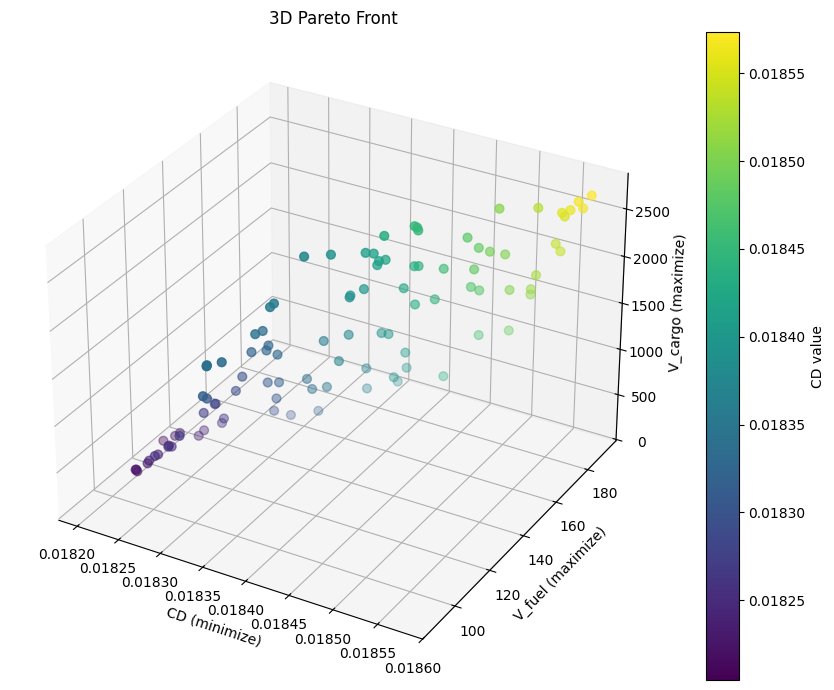

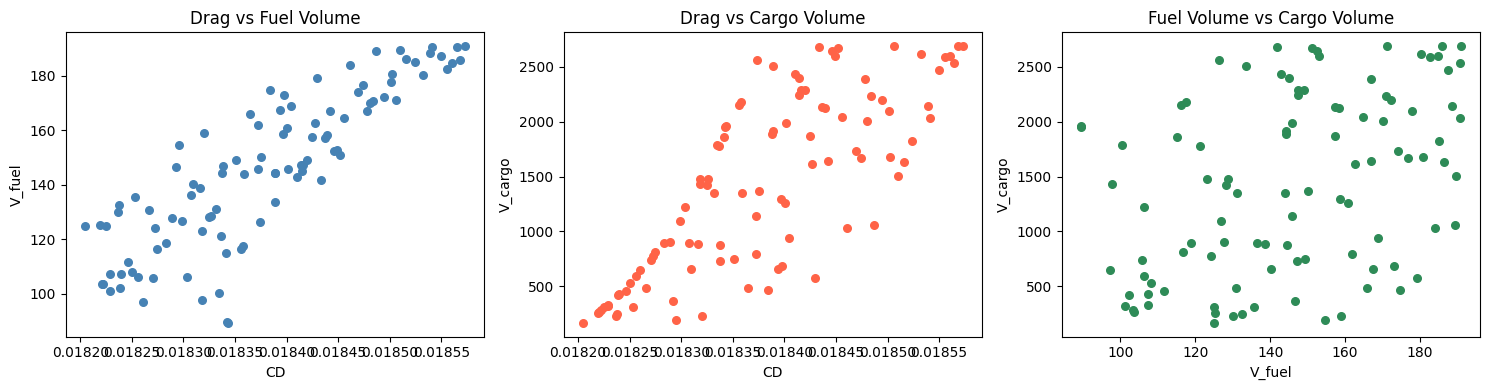

Best design (min drag):
  CD=0.01820, Vfuel=125.01, Vcargo=168.00
Best design (max fuel):
  CD=0.01857, Vfuel=190.89, Vcargo=2688.00
Best design (max cargo):
  CD=0.01857, Vfuel=190.89, Vcargo=2688.00


In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Convert back to original objective directions for plotting
CD_vals    = pareto_objectives[:, 0]
Vfuel_vals = -pareto_objectives[:, 1] #flip sign back to positive
Vcargo_vals = -pareto_objectives[:, 2] #same as the Vfuel

#3D Pareto Front
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(CD_vals, Vfuel_vals, Vcargo_vals, c=CD_vals, cmap='viridis', s=40)
# x axis = CD, y axis = Vfuel, z axis = Vcargo
# c=CD_vals → color each point by its drag value
# cmap='viridis' → color scale from purple (low drag) to yellow (high drag)
ax.set_xlabel('CD (minimize)')
ax.set_ylabel('V_fuel (maximize)')
ax.set_zlabel('V_cargo (maximize)')
ax.set_title('3D Pareto Front')
# label all three axes and add title

plt.colorbar(sc, label='CD value')
# add color bar on the side showing what colors mean
plt.tight_layout()
plt.show()

#2D Pairwise Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(CD_vals, Vfuel_vals, c='steelblue', s=30)
axes[0].set_xlabel('CD'); axes[0].set_ylabel('V_fuel')
axes[0].set_title('Drag vs Fuel Volume')
# plot 1: drag vs fuel
# shows trade- off: lower drag designs may store less fuel

axes[1].scatter(CD_vals, Vcargo_vals, c='tomato', s=30)
axes[1].set_xlabel('CD'); axes[1].set_ylabel('V_cargo')
axes[1].set_title('Drag vs Cargo Volume')
# plot 2: drag vs cargo
#show trade-off : lower drag often means smaller fuselage= less cargo

axes[2].scatter(Vfuel_vals, Vcargo_vals, c='seagreen', s=30)
axes[2].set_xlabel('V_fuel'); axes[2].set_ylabel('V_cargo')
axes[2].set_title('Fuel Volume vs Cargo Volume')
#plot 3 : fuel vs cargo
# shows trade-off:bigger wings= more fuel but fuselage drag may differ


plt.tight_layout()
plt.show()

# --- Print best designs per objective ---
print("Best design (min drag):")
idx = np.argmin(CD_vals)
print(f"  CD={CD_vals[idx]:.5f}, Vfuel={Vfuel_vals[idx]:.2f}, Vcargo={Vcargo_vals[idx]:.2f}")

print("Best design (max fuel):")
idx = np.argmax(Vfuel_vals)
print(f"  CD={CD_vals[idx]:.5f}, Vfuel={Vfuel_vals[idx]:.2f}, Vcargo={Vcargo_vals[idx]:.2f}")

print("Best design (max cargo):")
idx = np.argmax(Vcargo_vals)
print(f"  CD={CD_vals[idx]:.5f}, Vfuel={Vfuel_vals[idx]:.2f}, Vcargo={Vcargo_vals[idx]:.2f}")
# these three prints show the extreme corners of the Pareto front
# each one is best at one objective but likely worse at the other two